In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
import jax
jax.config.update("jax_enable_x64", True)

## Monolayer

#### How to create basic crystal?

In [5]:
"""
How to create a basic 2D monolayer crystal

In this section we:
  1. Define a primitive 2D unit cell (rectangular).
  2. Build a finite supercell from the primitive cell.
  3. Generate one particle per lattice site in the supercell.
"""
import numpy as np
import jax.numpy as jnp
from ezwald import geometry as geo

# 1. Primitive cell: rectangular lattice (aspect ratio lambda < 1)
lam = 0.95         # aspect ratio a1/a2
a2 = 1.0           # lattice constant along y
a1 = lam * a2      # lattice constant along x

# Each row is a lattice vector
axes_primitive = np.diag([a1, a2])

# 2. Build a supercell by tiling the primitive cell
nx = 2             # number of repeats in x and y
axes = nx * axes_primitive

# 3. Generate lattice positions: one particle per lattice site
fracs = axes / np.array((nx, nx))[:, None]
pos = geo.gen_lattice(fracs, (nx, nx), kspace=False)

print("Primitive cell axes:\n", axes_primitive)
print("Supercell axes:\n", axes)
print("Number of particles:", len(pos))

Primitive cell axes:
 [[0.95 0.  ]
 [0.   1.  ]]
Supercell axes:
 [[1.9 0. ]
 [0.  2. ]]
Number of particles: 4


#### How to visualize the lattice?

/home/jovyan/.cache/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-jzkag0sv because there was an issue with the default path (/home/jovyan/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Text(0.5, 1.0, '2D monolayer supercell')

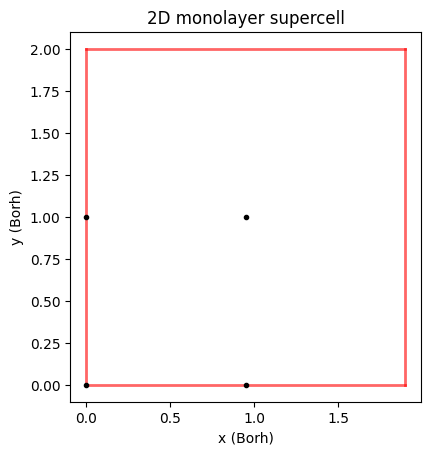

In [3]:
"""
How to graph a crystal configuration

We:
  1. Draw the simulation cell.
  2. Plot particle positions inside the cell.
"""
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)

# Draw the supercell in red
draw_cell(ax, axes, color="r")

# Plot particle positions as dots
ax.plot(*pos.T, ls="", marker=".", color="k")

ax.set_xlabel("x (Borh)")
ax.set_ylabel("y (Borh)")
ax.set_title("2D monolayer supercell")

#### How to get energy of a crystal

In [8]:
"""
How to compute Coulomb energy of a crystal with ezwald

We:
  1. Build an Ewald object for the supercell.
  2. Assign charges to each particle.
  3. Compute total and per-particle Coulomb energy.
"""
from ezwald import ewald

# 1. Build Ewald object and real/k-space lattice vectors
ew, rvecs, kvecs = ewald.make_ewald(axes)

# 2. Assign charges: here we take all particles to have charge -1
charge = -jnp.ones(len(pos))

# 3. Compute total Coulomb energy using Ewald summation
total_energy = ew.sum(pos, charge, rvecs, kvecs)
energy_per_particle = total_energy / len(pos)

print("N =", len(pos))
print("E_total =", float(total_energy))
print("E/N =", float(energy_per_particle))

N = 4
E_total = -7.999751040539559
E/N = -1.9999377601348898


#### How to know its correct

In [9]:
"""
How to compare with reference results (from Bonsall–Maradudin)
The paper quotes energies in the form

    E_l(λ) = -3.898597 * e^2 / (a_c)^(1/2)    for λ = 0.95,  Eq. (2.20)
This formula will be different for each crystal, reference paper for different formulas.

where:
  - E_l(λ) is the energy per *lattice site* (per particle),
  - e is the electron charge (we set e = 1),
  - a_c is the area (2D “volume”) of the primitive cell.

To compare our ezwald result to the paper:

  1. Compute the primitive cell area a_c from the 2×2 primitive axes matrix.
  2. Compute the total Coulomb energy E_total from ezwald.
  3. Convert to energy per particle E_num = E_total / N.
  4. Form the *dimensionless* energy

         E_dimless = E_num * (a_c)**0.5 / e**2

     (with e = 1, this is just E_num * sqrt(a_c)).
  5. Compare new E_dimless to the tabulated coefficient (-3.898597 for λ = 0.95).
  
Reference:
  "Some static and dynamical properties of a two-dimensional Wigner crystal"
  L. Bonsall and A. A. Maradudin, Phys. Rev. B 15, 1959 (1977).
"""

'\nHow to compare with reference results (from Bonsall–Maradudin)\nThe paper quotes energies in the form\n\n    E_l(λ) = -3.898597 * e^2 / (a_c)^(1/2)    for λ = 0.95,  Eq. (2.20)\nThis formula will be different for each crystal, reference paper for different formulas.\n\nwhere:\n  - E_l(λ) is the energy per *lattice site* (per particle),\n  - e is the electron charge (we set e = 1),\n  - a_c is the area (2D “volume”) of the primitive cell.\n\nTo compare our ezwald result to the paper:\n\n  1. Compute the primitive cell area a_c from the 2×2 primitive axes matrix.\n  2. Compute the total Coulomb energy E_total from ezwald.\n  3. Convert to energy per particle E_num = E_total / N.\n  4. Form the *dimensionless* energy\n\n         E_dimless = E_num * (a_c)**0.5 / e**2\n\n     (with e = 1, this is just E_num * sqrt(a_c)).\n  5. Compare new E_dimless to the tabulated coefficient (-3.898597 for λ = 0.95).\n\nReference:\n  "Some static and dynamical properties of a two-dimensional Wigner cry

#### How to generate different crystals

In [10]:
"""
How to generate different 2D Bravais lattices

You can change the primitive cell matrix `axes_primitive` to:
  - Oblique
  - Primitive rectangular
  - Centered rectangular
  - Square
  - Hexagonal

The Bonsall–Maradudin paper lists lattice vectors for each case.
"""
import numpy as np
from ezwald import geometry as geo

# Example: a rectangular lattice with aspect ratio lambda < 1
lam = 0.95
a2 = 1.0
a1 = lam * a2
axes_primitive = np.diag([a1, a2])

# Then proceed as in 'How to create basic crystal':
nx = 2
axes = nx * axes_primitive
latvec = axes / np.array((nx, nx))[:, None]
pos = geo.gen_lattice(latvec, (nx, nx), kspace=False)

#### How to tile a crystal

In [11]:
"""
How to tile a crystal from a smaller reference cell

We:
  1. Define a reference cell and positions inside it.
  2. Use `geo.tile` to build a larger tiled cell and positions.
"""
from ezwald import geometry as geo

# 1. Reference cell (e.g. 2x2 square lattice with a two-particle basis)
alat = 1.0
reg_cell = 2 * np.array([[alat, 0.0],
                         [0.0,  alat]])

# Two displacement vectors for the basis (here in lattice coordinates)
disp = np.array([[0.0, 0.0],
                 [0.5, 0.5]]) / 2.0

# Reference basis positions inside the cell (lattice coordinates)
x0 = np.array([[0.0, 0.0],
               [0.5, 0.0],
               [0.0, 0.5],
               [0.5, 0.5]])

# Combine basis + displacements and map to Cartesian
x = np.concatenate([_disp + x0 for _disp in disp])
reg_pos = x @ reg_cell

# 2. Tiling factors in x and y
nx = 2
ny = 3
cell = np.diag((nx, ny)) @ reg_cell
pos = geo.tile(reg_pos, (nx, ny), reg_cell)

print("Reference cell:\n", reg_cell)
print("Tiled cell:\n", cell)
print("Number of particles:", len(pos))

Reference cell:
 [[2. 0.]
 [0. 2.]]
Tiled cell:
 [[4. 0.]
 [0. 6.]]
Number of particles: 48


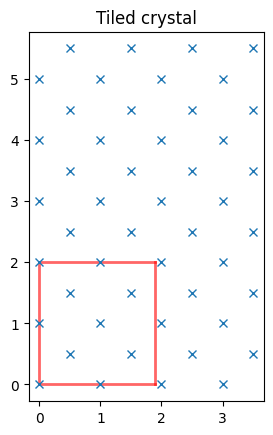

In [12]:
"""
Optional: visualize the tiled crystal
"""
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)

draw_cell(ax, axes, color='r')
ax.plot(*pos.T, ls='', marker='x')

ax.set_title("Tiled crystal")
plt.show()

#### How to use optimization to relax the crystal

In [13]:
import jax.numpy as jnp
import numpy as np
from ezwald import ewald, lattice, geometry as geo

#Refer to "How to create basic crystal" guide
lam = 0.95         
a2 = 1.0          
a1 = lam * a2   
axes_primitive = np.diag([a1, a2])
nx = 2            
axes = nx * axes_primitive
latvec = axes / np.array((nx, nx))[:, None]
pos = geo.gen_lattice(latvec, (nx, nx), kspace=False)

@jax.jit
def step(params, opt_state):
    loss_value, grads = grad_fn(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_value

# geomtry optimization
import optax
schedule = optax.exponential_decay(0.2, 1000, 0.5)
optimizer = optax.chain(
    optax.clip(1.0),
    optax.adam(schedule),
)
ew, rvecs, kvecs = ewald.make_ewald(axes)
rc, kc = lattice.compute_cutoffs(axes, 15.0)
latidx = lattice.lattice_indices(axes, rc, kc)
rvecs, kvecs = lattice.transform_lattice(latidx, axes)
charge = -1*jnp.ones(len(pos))
ew.sum(pos, charge, rvecs, kvecs)
nstep = 1000

# Follow guide for either positions or positions and cell optimization

##### Optimize Positions

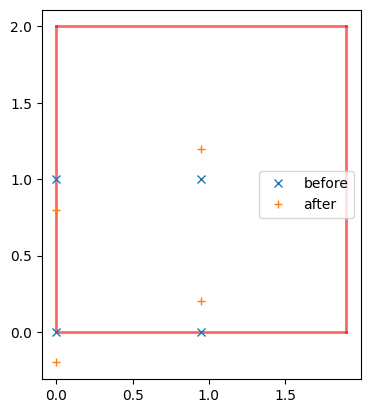

In [15]:
#The loss functions changes if optimizing positions vs positions and cell 
@jax.jit
def loss(params):
    pos = params
    return ew.sum(pos, charge, rvecs, kvecs)

loss(pos)
grad_fn = jax.jit(jax.value_and_grad(loss))
grad_fn(pos)
opt_state = optimizer.init(pos)
params = pos.copy()
nstep = 1000
for i in range(nstep):
    params, opt_state, loss_value = step(params, opt_state)

#Visualize 
import matplotlib.pyplot as plt
from vis import draw_cell
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, axes, color='r')

ax.plot(*pos.T, ls='', marker='x', label='before') #Unoptimized
ax.plot(*params.T, ls='', marker='+', label='after') #Optimized

ax.legend()

##### Optimize Positions and Cell

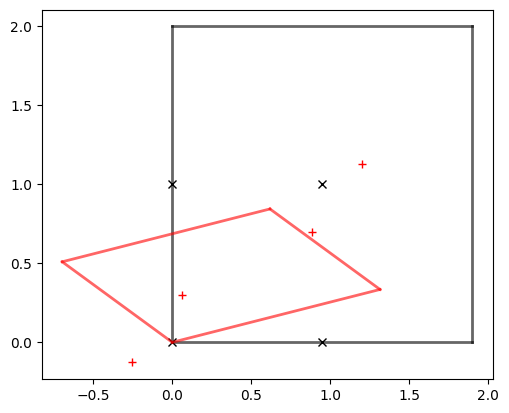

In [10]:
#The loss functions changes if optimizing positions vs positions and cell 
@jax.jit
def loss(params):
    axes = params['axes']
    rvecs, kvecs = lattice.transform_lattice(latidx, axes)
    pos = params['pos']
    return ew.sum(pos, charge, rvecs, kvecs)

grad_fn = jax.jit(jax.value_and_grad(loss))

params = {
    'axes': axes,
    'pos': pos,
}

opt_state = optimizer.init(params)
for i in range(nstep):
    params, opt_state, loss_value = step(params, opt_state)


axes1 = params['axes']
pos1 = params['pos']

#Visualize 
import matplotlib.pyplot as plt
from vis import draw_cell
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, axes, color='k')
ax.plot(*pos.T, ls='', marker='x', c='k') #Unoptimized

draw_cell(ax, axes1, color='r')
ax.plot(*pos1.T, ls='', marker='+', c='r' )#Optimized

#### How to show defects (Odd number of charges, different charge, and randomize position of charges)

Text(0.5, 1.0, '2D monolayer supercell')

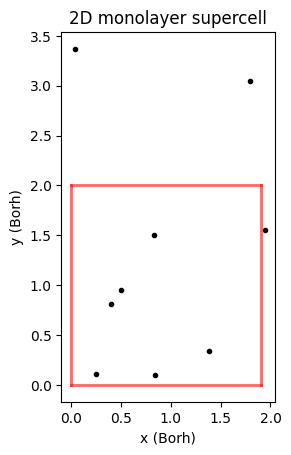

In [11]:
#To show defects: have an odd number of charges, change charge to be positive, and randomize positions of charges

#Define number of charges:
ntotalelectrons = 9 #Can make odd to see what interesting crystals form

#Define primitive cell:
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
]) #rectangular

#Randomizes position of charges:
fraction_cord = np.random.rand(ntotalelectrons, 2) #num points, dimensions, goes between 0 and 1
pos = fraction_cord@cell

#Create cell:
lam = 0.95         # aspect ratio a1/a2
a2 = 1.0           # lattice constant along y
a1 = lam * a2      # lattice constant along x
axes_primitive = np.diag([a1, a2])
nx = 2             # number of repeats in x and y
axes = nx * axes_primitive
ew, rvecs, kvecs = ewald.make_ewald(axes)

#Adjust charge here:
charge = jnp.ones(len(pos)) #redefine charge to positive to allow for holes

#Compute energy:
total_energy = ew.sum(pos, charge, rvecs, kvecs)
energy_per_particle = total_energy / len(pos)

#Plots:
import matplotlib.pyplot as plt
from vis import draw_cell
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, axes, color="r")
ax.plot(*pos.T, ls="", marker=".", color="k")
ax.set_xlabel("x (Borh)")
ax.set_ylabel("y (Borh)")
ax.set_title("2D monolayer supercell")

#### How to go from monolayer to bilayer

In [ ]:
# 1. Define unit cell: 2x2 rectangular (each row is a lattice vector) (with aspect ratio lambda < 1)
lam = 0.95
a2 = 1.0
a1 = lam * a2
axes_primitive = np.diag([a1, a2])

# Supercell axes (scaled by nx)
nx = 2
axes = nx * axes_primitive

# 2. Put one particle per lattice site for supercell
latvec = axes / np.array((nx, nx))[:, None]
pos = geo.gen_lattice(latvec, (nx, nx), kspace=False)

## Bilayer

#### How to create basic crystal

In [4]:
"""
How to create a basic 2D bilayer crystal

In this section we:
  1. Define a primitive 2D unit cell for the bilayer.
  2. Specify the relative layer displacements within the unit cell.
  3. Generate particle positions for both layers.
"""
import numpy as np

# 1. Primitive cell: rectangular supercell for a 2D bilayer
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
])

# 2. Layer displacements: offset each layer within the unit cell
disp = np.array([[0,0],[0.5, 0.5]]) /2

# 3. Basis positions: four sites per layer, then combine both layers
x0 = np.array([[0,0],[0.5,0],[0,0.5],[0.5,0.5]])
x = np.concatenate([_disp + x0 for _disp in disp])
pos = x@cell

print("Unit cell axes:\n", cell)
print("Number of particles:", len(pos))
print("Particle positions:\n", pos)

Unit cell axes:
 [[2.         0.        ]
 [0.         3.46410162]]
Number of particles: 8
Particle positions:
 [[0.         0.        ]
 [1.         0.        ]
 [0.         1.73205081]
 [1.         1.73205081]
 [0.5        0.8660254 ]
 [1.5        0.8660254 ]
 [0.5        2.59807621]
 [1.5        2.59807621]]


#### How to graph

Text(0.5, 1.0, '2D bilayer supercell')

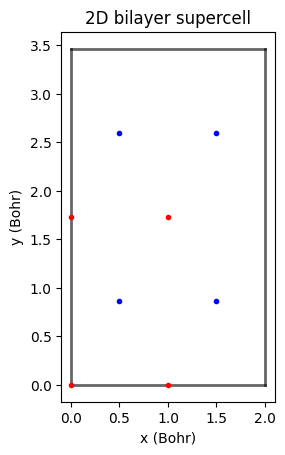

In [15]:
"""
How to graph a crystal configuration

We:
  1. Draw the simulation cell.
  2. Plot particle positions inside the cell.
"""
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)

# Draw the supercell in black
draw_cell(ax, cell, color="k")

# Plot particle positions as dots
pos_t, pos_b = np.array_split(pos,2) #splits layers for visualization
ax.plot(*pos_t.T, ls="", marker=".", color="r") #red
ax.plot(*pos_b.T, ls="", marker=".", color="b") #blue

ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("2D bilayer supercell")

#### How to get energy of a crystal

In [19]:
"""
How to compute Coulomb energy of a bilayer crystal with ezwald

We:
  1. Build a slab Ewald object for the bilayer supercell.
  2. Assign charges to each particle in both layers.
  3. Compute total and per-particle Coulomb energy, and an optional rescaled energy.
"""
import numpy as np
import jax.numpy as jnp
from ezwald import bilayer_sum

# 1. Build Ewald slab object for the bilayer
#    Here `cell` is the in-plane lattice matrix and `d` is the interlayer spacing.
d = 1.5
bew = bilayer_sum.EwaldSumSlab(cell, d)

# 2. Assign charges: here we take all particles to have charge -1 (in units of e)
charge = -jnp.ones(len(pos))

# 3. Compute total Coulomb energy using the bilayer Ewald summation
total_energy = bew.energy(charge, pos)
energy_per_particle = total_energy / len(pos)

# Optional: define an energy rescaling based on an areal density n used later when how to know its correct
n = len(pos) / abs(np.linalg.det(cell))   # particles per unit area
energy_rescaling = total_energy / jnp.sqrt(n)

print("N =", len(pos))
print("E_total =", float(total_energy))
print("E/N =", float(energy_per_particle))
print("Rescaled energy =", float(energy_rescaling))

N = 8
E_total = -11.27061201889377
E/N = -1.4088265023617212
Rescaled energy = -10.488486309837066


#### How to know its correct

In [20]:
"""
How to compare with reference results (from Goldoni–Peeters)

The paper quotes bilayer energies in the dimensionless form

    E / (e^2 * sqrt(n))                                      (their Eqs. (16)–(17))

where:
  - E is the total energy per particle (per electron),
  - e is the electron charge (we set e = 1),
  - n is the total 2D particle density (both layers combined).

To compare our ezwald bilayer result to the paper:

  1. Compute the total areal density
         n = N / A
     where N is the total number of particles in both layers and
     A is the in-plane area of the simulation cell, A = det(cell).

  2. Compute the total Coulomb energy E_total from the bilayer Ewald sum.
     The ezwald bilayer routine gives E_total for the N-particle system.

  3. Convert to energy per particle
         E_num = E_total / N.

  4. Form the *dimensionless* energy used in the paper

         E_dimless = E_num / (e^2 * sqrt(n))

     (with e = 1, this is just E_num / sqrt(n)).

  5. For a given value of the dimensionless parameter
         η = d * sqrt(n / 2)
     (their definition), evaluate the analytic expression for
     E / (e^2 * sqrt(n)) from Eqs. (16)–(17) and compare
     to our numerical E_dimless as a function of η.

Reference:
  "Stability, dynamical properties, and melting of a classical bilayer
   Wigner crystal", G. Goldoni and F. M. Peeters,
   Phys. Rev. B 53, 4591 (1996).
"""
import numpy as np
import jax.numpy as jnp

# 1. Total areal density n from the bilayer simulation cell
N = len(pos)                          # total number of particles (both layers)
A = abs(np.linalg.det(cell))          # in-plane cell area
n = N / A                             # total 2D density

# 2. Total Coulomb energy from bilayer Ewald sum (see previous section)
total_energy = bew.energy(charge, pos)

# 3. Energy per particle
energy_per_particle = total_energy / N

# 4. Dimensionless energy E / (e^2 * sqrt(n)), with e = 1
E_dimless = energy_per_particle / jnp.sqrt(n)

# 5. Dimensionless interlayer parameter η used in the paper
eta = d * jnp.sqrt(n / 2.0)

print("N =", int(N))
print("Area A =", float(A))
print("Density n =", float(n))
print("η =", float(eta))
print("E_per_particle =", float(energy_per_particle))
print("E / (e^2 * sqrt(n)) =", float(E_dimless))

N = 8
Area A = 6.928203230275509
Density n = 1.1547005383792517
η = 1.139753528477389
E_per_particle = -1.4088265023617212
E / (e^2 * sqrt(n)) = -1.3110607887296333


#### How to generate different crystals

In [21]:
"""
How to generate different bilayer crystal phases

You can change the primitive cell matrix `cell` and the layer offset `disp`
to generate the five bilayer phases:
  - Phase I: one-component hexagonal
  - Phase II: staggered rectangular
  - Phase III: staggered square
  - Phase IV: staggered rhombic
  - Phase V: staggered hexagonal

The Goldoni–Peeters paper lists the primitive vectors a1, a2
and interlayer displacement c for each case.
"""
import numpy as np

# Example: Phase III (staggered square)
a = 1.0
cell = a * np.array([
    [1.0, 0.0],
    [0.0, 1.0],
])

# Relative offset between the two layers
disp = 0.5 * (cell[0] + cell[1])

# One particle basis for each layer
x0 = np.array([[0.0, 0.0]])
x = np.concatenate([x0, x0 + disp])
pos = x @ cell

#### How to tile a crystal

In [33]:
"""
How to tile a bilayer crystal from a smaller reference cell

We:
  1. Define a reference bilayer cell and positions inside it.
  2. Tile the configuration to build a larger bilayer supercell.
"""
import numpy as np
from ezwald import geometry as geo

def tile(pos, mesht, cell):
    """Tile positions `pos` over an integer mesh using lattice vectors `cell`."""
    ndim = len(cell)
    rvecs = geo.gen_lattice(cell, mesht, kspace=False)
    all_pos = rvecs[:, None] + pos[None, :]
    pos1 = all_pos.reshape(-1, ndim)
    return pos1

# 1. Reference bilayer cell (hexagonal-type 2x2 cell)
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
])

# Two layer displacements in lattice coordinates
disp = np.array([[0,0],[0.5, 0.5]]) /2

# Four-site basis in lattice coordinates
x0 = np.array([[0,0],[0.5,0],[0,0.5],[0.5,0.5]])

# Combine basis + layer displacements and map to Cartesian
x = np.concatenate([_disp + x0 for _disp in disp])
pos = x@cell

# For visualization: split positions into top/bottom layers
pos_t, pos_b = np.array_split(pos,2) #splits layers for visualization

# 2. Tiling factors in x and y
nx, ny = 2, 2
pos_top_tiled = tile(pos_t, (nx, ny), cell)
pos_bottom_tiled = tile(pos_b, (nx, ny), cell)
pos_tiled = np.concatenate([pos_top_tiled, pos_bottom_tiled], axis=0)

print("Reference cell:\n", cell)
print("Number of particles (tiled):", len(pos_tiled))

Reference cell:
 [[2.         0.        ]
 [0.         3.46410162]]
Number of particles (tiled): 32


Text(0.5, 1.0, 'Tiled crystal')

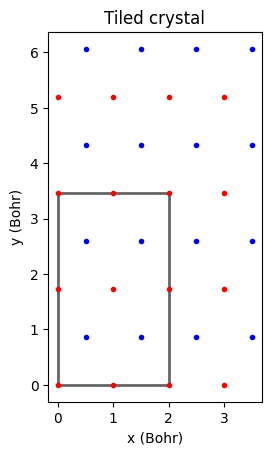

In [34]:
"""
Optional: visualize the tiled crystal
"""
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)

# Draw the supercell in black
draw_cell(ax, cell, color="k")

# Plot particle positions as dots
ax.plot(*pos_top_tiled.T, ls="", marker=".", color="r") #red
ax.plot(*pos_bottom_tiled.T, ls="", marker=".", color="b") #blue

ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("Tiled crystal")

#### How to use optimization to relax the crystal

In [45]:
import jax.numpy as jnp
import numpy as np

#Refer to "How to create basic crystal" guide
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
])
disp = np.array([[0,0],[0.5, 0.5]]) /2
x0 = np.array([[0,0],[0.5,0],[0,0.5],[0.5,0.5]])
x = np.concatenate([_disp + x0 for _disp in disp])
pos = x@cell

@jax.jit
def step(params, opt_state):
    loss_value, grads = grad_fn(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_value

# geomtry optimization
import optax
schedule = optax.exponential_decay(init_value=0.2, transition_steps=1000, decay_rate=0.5)
optimizer = optax.chain(
    optax.clip(1.0),
    optax.adam(schedule),
)

charge = -1*jnp.ones(len(pos)) #This is e
d= 1.3 #change this distance between layers
bew = bilayer_sum.EwaldSumSlab(cell, d)
e = bew.energy(charge, pos)/len(pos)
nstep = 1000

# Follow guide for either positions or positions and cell optimization

##### Optimize Positions

Text(0.5, 1.0, 'Optimized: top(blue) and bottom(red)')

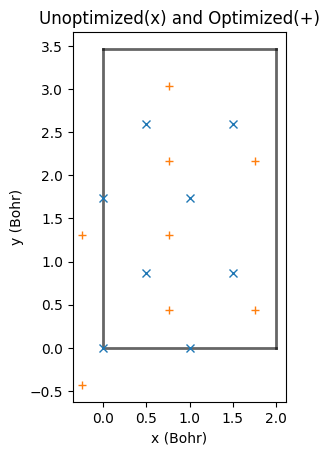

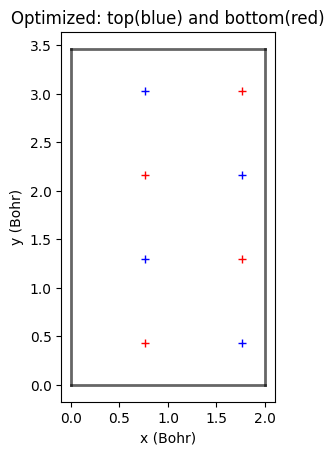

In [46]:
#The loss functions changes if optimizing positions vs positions and cell 
@jax.jit
def loss(params):
    pos = params
    charge = -1*jnp.ones(len(pos))
    return bew.energy(charge, pos)/len(pos)

# Evaluate loss and its gradient at the initial configuration
loss(pos)
grad_fn = jax.jit(jax.value_and_grad(loss))
grad_fn(pos)

# Run gradient-based optimization on the positions
opt_state = optimizer.init(pos)
params = pos.copy()
for i in range(nstep): #actual opt
    params, opt_state, loss_value = step(params, opt_state)

# Visualize initial vs optimized bilayer configuration
import matplotlib.pyplot as plt
from vis import draw_cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, cell, color='k')

ax.plot(*pos.T, ls='', marker='x') #Unoptimized
ax.plot(*params.T, ls='', marker='+') #Optimized
ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("Unoptimized(x) and Optimized(+)")

# Visualize both optimized layers separately inside one primitive cell
np.linalg.inv(cell) 
fracs = params @ np.linalg.inv(cell) # Cartesian -> fractional coordinates
fracs %1                             # Wrap into [0, 1)
pos1 = (fracs%1)@cell                # Back to Cartesian in reference cell

pos_t, pos_b = np.array_split(pos1,2) 

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, cell, color='k')
ax.plot(*pos_b.T, ls='', marker='+', color='b')
ax.plot(*pos_t.T, ls='', marker='+', color='r')
ax.set_xlabel("x (Bohr)")
ax.set_ylabel("y (Bohr)")
ax.set_title("Optimized: top(blue) and bottom(red)")

##### Optimize Positions and Cell

In [ ]:
#The loss functions changes if optimizing positions vs positions and cell 
@jax.jit
def loss(params):
    a = params["a"]
    theta = params["theta"]
    cell = make_cell(areac, a, theta)
    pos = params["pos"]
    recvec = geo.calc_recvec(cell)
    gpoints = gidx @ recvec
    bew =  bilayer_sum.EwaldSumSlab(cell, d, disp_fn_mode='gen', gpoints = gpoints)
    return bew.energy(charge, pos)/len(pos)

#### How to show defects

In [ ]:
ntotalelectrons = 8
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
]) #rectangular
fraction_cord = np.random.rand(ntotalelectrons, 2)#num points, dimensions, goes between 0 and 1
pos = fraction_cord@cell

#### Stuff

In [ ]:
# know its correct
#formula 16 n is bilayer density

In [ ]:
# diff charges
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
from ezwald import ewald, lattice, bilayer_sum, geometry as geo
from vis import draw_cell
# import os
# os.environ['JAX_PLATFORMS'] = 'cpu'
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

ntotalelectrons = 16
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
]) # rectangular

fraction_cord = np.random.rand(ntotalelectrons, 2)
pos = fraction_cord @ cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, cell, color='r')
ax.plot(*pos.T, ls='', marker='x')

# Layer assignment: split positions
midpoint = ntotalelectrons // 2

# charge = 1*jnp.ones(len(pos)) #This is e

# bew = bilayer_sum.EwaldSumSlab(cell, d)
# e = bew.energy(charge, pos) / len(pos)
# print(e)

In [ ]:
@jax.jit
def step(params, opt_state):
    loss_value, grads = grad_fn(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_value

# geomtry optimization
import optax
schedule = optax.exponential_decay(init_value=0.2, transition_steps=1000, decay_rate=0.5)
optimizer = optax.chain(
    optax.clip(1.0),
    optax.adam(schedule),
)

charge = -1*jnp.ones(len(pos)) #This is e
d= 1 #change this between 3->2 and 1.9->1.5 big change
bew = bilayer_sum.EwaldSumSlab(cell, d)
e = bew.energy(charge, pos)/len(pos)
nstep = 1000

In [ ]:
def make_cell(area, a, theta):
    b = area/(a*jnp.sin(theta))
    cell = jnp.array([
        [a, 0],
        [b*jnp.cos(theta), b*jnp.sin(theta)],
    ])
    return cell

areac = abs(np.linalg.det(cell))
make_cell(areac, cell[0,0], np.pi/3) #opt cell

In [ ]:
params = {
    'a':  cell[0,0],
    'theta': np.pi/2,
    'pos': pos,
}

bew = bilayer_sum.EwaldSumSlab(cell, d)

recvec = geo.calc_recvec(cell)
gcands = bew.gpoints @ np.linalg.inv(recvec)
gidx = np.array(gcands.round(), dtype=int) #preacllocated
np.allclose(gidx, gcands)
# print(gidx)

In [ ]:
origin = pos1[0]
pos1 = pos1 - origin

fracs = pos1 @ np.linalg.inv(cell1) #takes to fractional
fracs %1

pos2 = (fracs%1)@cell1
# pos_t, pos_b = np.array_split(pos2,2) #splits layers
ntot = len(pos2)
nup = ntot//2
pos_t = pos2[:nup]
pos_b = pos2[nup:]
# origin = pos_t[0]
# pos_t = pos_t - origin
# pos_b = pos_b - origin

def show_bilayer(ax, cell, pos, **kwargs):
    ntot = len(pos)
    nup = ntot//2
    draw_cell(ax, cell)
    if ('ls' not in kwargs) and ('linestyle' not in kwargs):
        kwargs['ls'] = ''
    if 'marker' not in kwargs:
        kwargs['marker'] = '.'
    ax.plot(*pos[:nup].T, **kwargs)
    ax.plot(*pos[nup:].T, **kwargs) 

print("After Cell and Pos Opt")
# draw_cell(ax, cell, color='k')
# show_bilayer(ax, cell1, pos2)

cell1 = make_cell(areac, params['a'], params['theta'])
pos1 = params['pos']
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)

# # After optimization
show_bilayer(ax, cell1, pos2)
draw_cell(ax, cell1, color='r')

# Labels and title
ax.set_xlabel('x (Bohr)')
ax.set_ylabel('y (Bohr)')
ax.set_title('After Optimization of Uneven charges')

In [ ]:
e = bew.energy(charge, pos1) / len(pos1)
print(e)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, cell1, color='r')
# show_bilayer(ax, cell1, pos3)
ax.plot(*pos_t.T, ls='', marker='.', c='orange')
ax.plot(*pos_b.T, ls='', marker='.', c='blue')

# Labels and title
ax.set_xlabel('x (Bohr)')
ax.set_ylabel('y (Bohr)')
ax.set_title('Body-Centered Rectangles')

In [ ]:
def tile(pos, mesht, cell):
    ndim = len(cell)
    # cell1 = np.diag(mesht) @ cell
    rvecs = geo.gen_lattice(cell, mesht, kspace=False)
    all_pos = rvecs[:, None] + pos[None, :]
    pos1 = all_pos.reshape(-1, ndim)
    return pos1

pos3_t = tile(pos_t, [2,2], cell1)
pos3_b = tile(pos_b, [2,2], cell1)
pos3 = np.concatenate([pos3_t,pos3_b], axis=0)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, cell1, color='r')
# show_bilayer(ax, cell1, pos3)
ax.plot(*pos3_t.T, ls='', marker='.', c='blue')
ax.plot(*pos3_b.T, ls='', marker='.', c='orange')

# Labels and title
ax.set_xlabel('x (Bohr)')
ax.set_ylabel('y (Bohr)')
ax.set_title('Tiling of Optimizated Uneven charges')

In [ ]:
e = bew.energy(charge, pos) / len(pos)
print(e)

In [ ]:
ntotalelectrons = 8
alat = 1
cell = 2 * np.array([
    [alat, 0],
    [0, np.sqrt(3) * alat]
]) # rectangular

# fraction_cord = np.random.rand(ntotalelectrons, 2)
pos = fraction_cord @ cell

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect=1)
draw_cell(ax, cell, color='r')
ax.plot(*pos.T, ls='', marker='x')

# Layer assignment: split positions
midpoint = ntotalelectrons // 2

charge = -1*jnp.ones(len(pos)) #This is e
charge = charge.at[0].set(1)          # First particle in layer 1
charge = charge.at[midpoint].set(1)   # First particle in layer 2


d = 5
bew = bilayer_sum.EwaldSumSlab(cell, d)
e = bew.energy(charge, pos) / len(pos)
print(e)